# Model Comparison

This notebook uses the `ExperimentRunner` to train and evaluate all models
(global linear, LWLR, MC, and MCLLR) on the Fama–French dataset.  It
demonstrates how to load configurations, run experiments, and inspect results.

In [1]:
import pandas as pd

from src.Experiments.runner import ExperimentRunner
from src.data.preprocessing import time_series_split


In [2]:
# specify configuration yaml (must exist in experiments/ folder)
config_path = "experiments/config_comparison.yaml"

runner = ExperimentRunner(config_path)
results_df = runner.run()

results_df

Loading dataset...
 {'n_samples': 816, 'n_features': 5, 'features': ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'], 'date_range': '1963-07-01 00:00:00to2025-10-01 00:00:00', 'source_hash': '9cb42506'}
Splitting data...
 Train: 652, Test: 164

Training global_linear...
 <EvaluationResult global_linear | rmse: 0.0430, mae: 0.0331, mape: 1.6328, r2: -0.0568, explained_variance: -0.0414, median_ae: 0.0278>

Training lwlr...


 <EvaluationResult lwlr | rmse: 0.0430, mae: 0.0330, mape: 1.6329, r2: -0.0565, explained_variance: -0.0411, median_ae: 0.0279>

Training mc_linear...
 <EvaluationResult mc_linear | rmse: 0.0431, mae: 0.0331, mape: 1.6627, r2: -0.0589, explained_variance: -0.0419, median_ae: 0.0279, coverage_95: 0.3841, avg_std: 0.0116>

Training mcllr...


 <EvaluationResult mcllr | rmse: 0.0431, mae: 0.0331, mape: 1.6266, r2: -0.0579, explained_variance: -0.0433, median_ae: 0.0278, coverage_95: 0.4024, avg_std: 0.0114>


,model,rmse,mae,mape,r2,explained_variance,median_ae,coverage_95,avg_std
0,global_linear,0.043042,0.033052,1.632833,-0.056799,-0.041407,0.027843,NaN,NaN
1,lwlr,0.043036,0.033048,1.632906,-0.056515,-0.041140,0.027905,NaN,NaN
2,mc_linear,0.043086,0.033131,1.662660,-0.058949,-0.041851,0.027854,0.384146,0.011585
3,mcllr,0.043064,0.033075,1.626648,-0.057868,-0.043293,0.027836,0.402439,0.011447


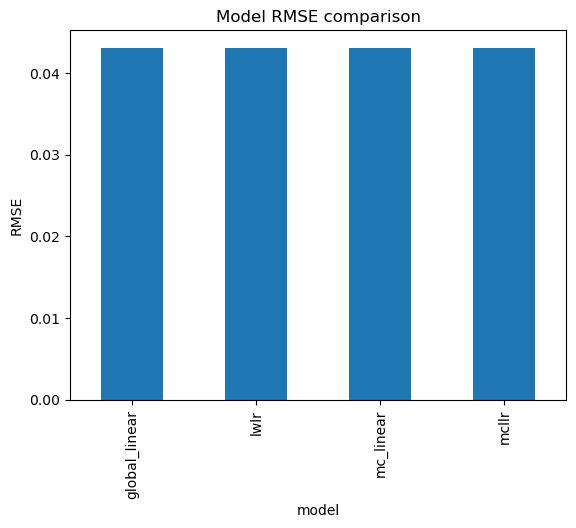

In [3]:
# simple bar chart of RMSE
import matplotlib.pyplot as plt

if not results_df.empty:
    results_df.plot.bar(x="model", y="rmse", legend=False)
    plt.ylabel("RMSE")
    plt.title("Model RMSE comparison")
    plt.show()

## Observations

After running the above, inspect the printed DataFrame and chart to compare
model performance. Use `runner.save_results()` if you want to persist these
metrics to disk.